## Análise Exploratória dos Dados (EDA):

O objetivo principal deste projeto é transformar dados operacionais em insights acionáveis para o negócio. Buscamos compreender quais fatores operacionais (como logística, atendimento e pedidos) influenciam a satisfação do cliente, identificar os perfis de promotores e detratores, e propor recomendações estratégicas de melhoria.

Perguntas Norteadoras:
- Quais fatores parecem mais críticos para a satisfação?
- O que mais gera detratores?
- Existe algum “ponto de ruptura” na experiência do cliente?
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?


### Setup do Notebook

In [26]:
#Instalação de Kernel no ambiente python
#!pip install -U ipykernel

#Instalação de bibliotecas (descomente se necessário)
#!pip install jupyter pandas numpy plotly seaborn matplotlib


# Importação de bibliotecas
import pandas as pd
import numpy as np

# Libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual e de avisos
import warnings
warnings.filterwarnings('ignore')

# Definindo o estilo padrão dos gráficos para um formato mais limpo (executivo)
sns.set_theme(style="whitegrid", palette="muted")

### Carregamento e Inspeção Inicial

In [27]:
# Carregando os dados brutos
# O caminho relativo '../data/desafio_nps_fase_1.csv' assume que seu notebook está dentro da pasta 'notebooks'
df = pd.read_csv('../data/desafio_nps_fase_1.csv')

# Inspeção inicial
print(f"A base possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# Verificando dados nulos e tipos de dados
display(df.info())

# Verificando valores duplicados (garantia de qualidade)
duplicados = df.duplicated().sum()
print(f"\nLinhas duplicadas encontradas: {duplicados}")

A base possui 2500 linhas e 19 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_c

None


Linhas duplicadas encontradas: 0


### Visão Geral e Estatísticas Descritivas do NPS

In [32]:
# 1. Estatísticas descritivas básicas da nota numérica
estatisticas_nps = df['nps_score'].describe()

# 2. Cálculo das proporções das categorias
total_clientes = len(df)
promotores = (df['nps_score'] >= 9).sum()
neutros = ((df['nps_score'] >= 7) & (df['nps_score'] < 9)).sum()
detratores = (df['nps_score'] < 7).sum()


# Cálculo oficial do índice NPS: % Promotores - % Detratores

# --- Exibição dos Resultados Estruturados ---
print("--- Estatísticas Descritivas da Nota NPS (0 a 10) ---")
print(f"Média das Notas: {estatisticas_nps['mean']:.2f}")
print(f"Mediana (Nota Central): {estatisticas_nps['50%']:.2f}")
print(f"Desvio Padrão (Dispersão): {estatisticas_nps['std']:.2f}")
print(f"Nota Mínima Registrada: {estatisticas_nps['min']:.1f}")
print(f"Nota Máxima Registrada: {estatisticas_nps['max']:.1f}")
print("-" * 50)
print("--- Distribuição de Clientes por Perfil ---")
print("-" * 50)


--- Estatísticas Descritivas da Nota NPS (0 a 10) ---
Média das Notas: 4.38
Mediana (Nota Central): 4.40
Desvio Padrão (Dispersão): 2.51
Nota Mínima Registrada: 0.0
Nota Máxima Registrada: 10.0
--------------------------------------------------
--- Distribuição de Clientes por Perfil ---
--------------------------------------------------


In [28]:
# Função para categorizar o NPS conforme a regra de mercado
def categorizar_nps(nota):
    if nota >= 9:
        return 'Promotor'
    elif nota >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

# Criando a nova coluna qualitativa
df['nps_class'] = df['nps_score'].apply(categorizar_nps)

# Ordenando as categorias para que os gráficos façam sentido visualmente
nps_order = ['Detrator', 'Neutro', 'Promotor']
df['nps_class'] = pd.Categorical(df['nps_class'], categories=nps_order, ordered=True)

# Visão gerencial inicial: Qual é a distribuição da nossa base?
distribuicao_nps = df['nps_class'].value_counts(normalize=True) * 100
print("Distribuição do Perfil de Clientes (%):")
print(distribuicao_nps.round(2))

Distribuição do Perfil de Clientes (%):
nps_class
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64



### Engenharia de Recursos (Preparando a Target)

### 1. Quais fatores parecem mais críticos para a satisfação? O que mais gera detratores?

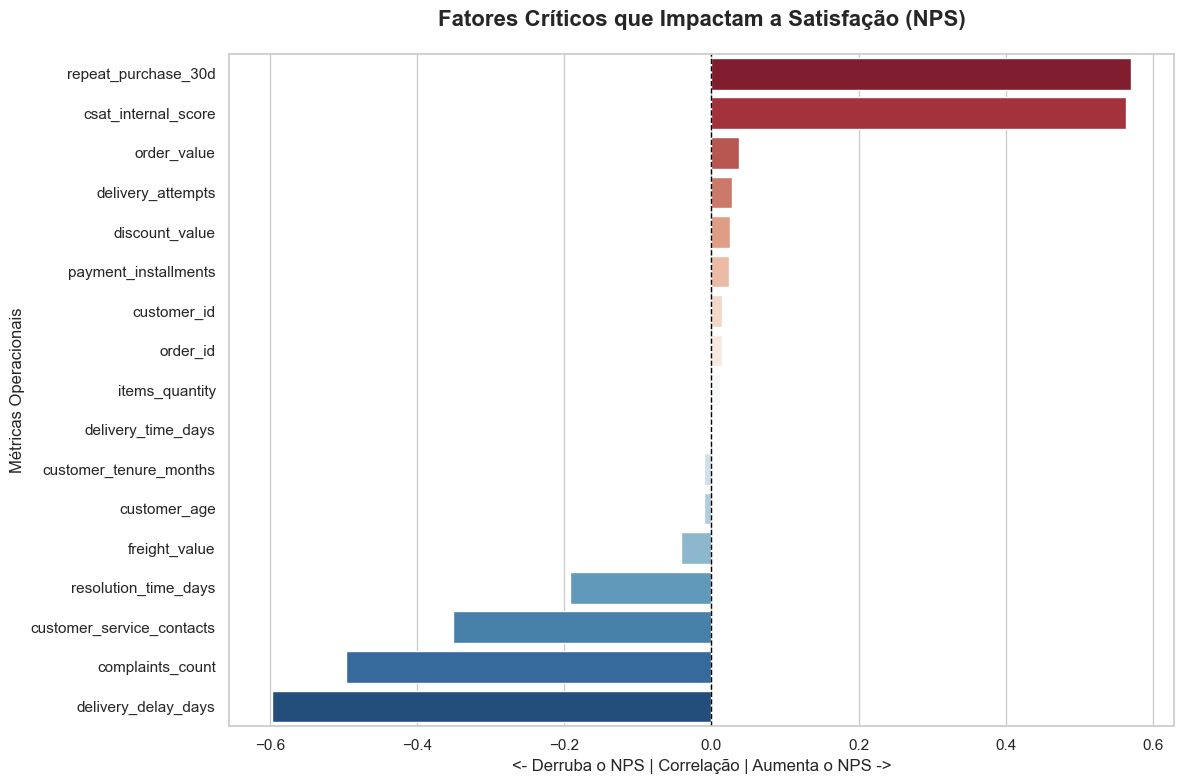

--- TOP 3 Fatores que DERRUBAM o NPS (Correlação Negativa) ---
delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
Name: nps_score, dtype: float64

--- TOP 3 Fatores que IMPULSIONAM o NPS (Correlação Positiva) ---
repeat_purchase_30d    0.570324
csat_internal_score    0.563952
order_value            0.036990
Name: nps_score, dtype: float64


In [8]:
# Selecionamos apenas as colunas numéricas para o cálculo matemático
colunas_numericas = df.select_dtypes(include=[np.number])

# Calculamos a correlação de todas as variáveis com o nps_score
correlacoes = colunas_numericas.corr()['nps_score'].sort_values(ascending=False)

# Removemos a própria variável nps_score (pois a correlação dela com ela mesma é 1)
correlacoes = correlacoes.drop('nps_score')

# --- Visualização Focada no Negócio ---
plt.figure(figsize=(12, 8))

# Criamos um gráfico de barras horizontal para facilitar a leitura dos nomes
# Usamos a paleta 'RdBu' (Red/Blue): Vermelho para negativo, Azul para positivo
sns.barplot(x=correlacoes.values, y=correlacoes.index, palette='RdBu')

plt.title('Fatores Críticos que Impactam a Satisfação (NPS)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('<- Derruba o NPS | Correlação | Aumenta o NPS ->', fontsize=12)
plt.ylabel('Métricas Operacionais', fontsize=12)

# Adiciona uma linha no zero para referência visual
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Ajuste de layout
plt.tight_layout()
plt.show()

# Imprimindo os top 3 maiores ofensores e impulsionadores
print("--- TOP 3 Fatores que DERRUBAM o NPS (Correlação Negativa) ---")
print(correlacoes.tail(3).sort_values())

print("\n--- TOP 3 Fatores que IMPULSIONAM o NPS (Correlação Positiva) ---")
print(correlacoes.head(3))

### Interpretação:
A operação logística é o maior gargalo da empresa. O atraso na entrega (delivery_delay_days) é o fator que mais afunda a percepção da marca. Por outro lado, processos internos que funcionam bem (csat_internal_score) são os que mais seguram a lealdade do cliente. Aqui também encontramos uma questãon de Correlação vs. Causalidade, o cliente não fica satisfeito porque recomprou. Ele recompra porque ficou satisfeito. A recompra é um comportamento consequente, não um fator gerador da nota. Para "tirar isso a limpo" e aprofundar a Análise Exploratória,  nós precisamos isolar as variáveis operacionais (aquelas que a empresa controla e que geram a nota) e analisar como elas se combinam.

### Aprofundamento: Fatores Operacionais vs Consequências

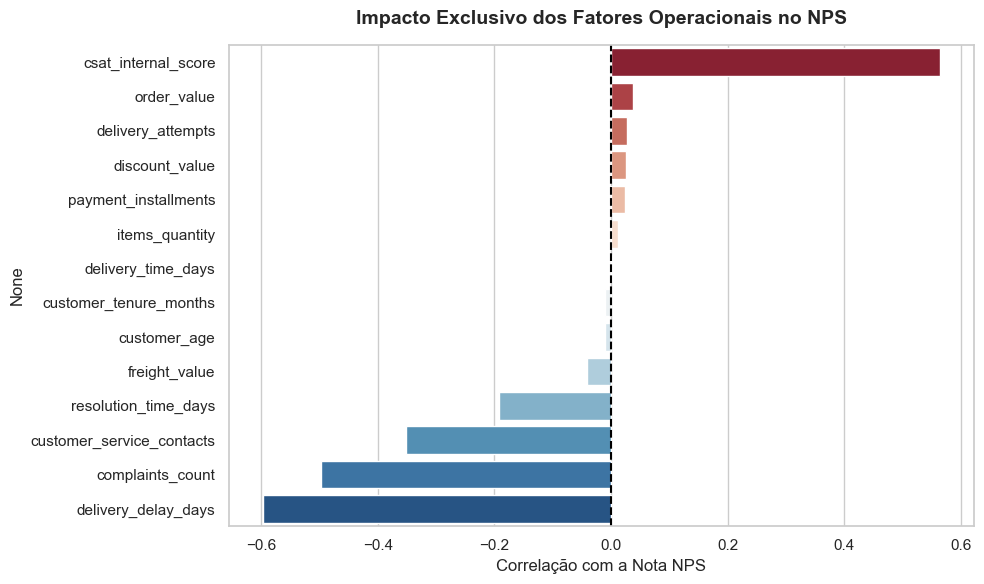

In [ ]:
# Vamos remover da nossa análise as variáveis que são "Efeitos" ou "Identificadores"
variaveis_para_remover = ['customer_id', 'order_id', 'repeat_purchase_30d']

# Filtramos apenas as variáveis de causa (operacionais e demográficas) numéricas
causas_operacionais = df.select_dtypes(include=[np.number]).drop(columns=variaveis_para_remover, errors='ignore')

# Recalculamos a correlação APENAS com as causas
correlacoes_causas = causas_operacionais.corr()['nps_score'].sort_values(ascending=False).drop('nps_score')

plt.figure(figsize=(10, 6))
sns.barplot(x=correlacoes_causas.values, y=correlacoes_causas.index, palette='RdBu')
plt.title('Impacto Exclusivo dos Fatores Operacionais no NPS', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Correlação com a Nota NPS')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


### 2. Existe algum "ponto de ruptura" na experiência do cliente?


In [20]:
# 1. Agrupar os dados calculando a média do NPS por dias de atraso
ruptura_df = df.groupby('delivery_delay_days')['nps_score'].mean().reset_index()
ruptura_df['nps_score'] = ruptura_df['nps_score'].round(2)

# 2. Criar o gráfico de linha com marcadores
fig_ruptura = px.line(
    ruptura_df,
    x='delivery_delay_days',
    y='nps_score',
    markers=True,
    title='Ponto de Ruptura: Impacto do Atraso na Nota Média do NPS',
    labels={
        'delivery_delay_days': 'Dias de Atraso na Entrega',
        'nps_score': 'Nota Média do NPS'
    },
    template='plotly_white'
)

# 3. Customizar a linha de tendência (cor vermelha para indicar alerta/risco)
fig_ruptura.update_traces(
    line=dict(color='#d9534f', width=3),
    marker=dict(size=10, color='#d9534f')
)

# 4. Adicionar linhas horizontais de referência (Limiares de nota do NPS)
fig_ruptura.add_hline(
    y=7.0, 
    line_dash="dash", 
    line_color="gray", 
    annotation_text="Limiar Promotor/Neutro (Nota 7.0)", 
    annotation_position="top left"
)

fig_ruptura.add_hline(
    y=6.0, 
    line_dash="dot", 
    line_color="black", 
    annotation_text="Limiar Detrator (Nota 6.0)", 
    annotation_position="bottom left"
)

# 5. Ajustar o layout do gráfico para apresentação gerencial
fig_ruptura.update_layout(
    xaxis=dict(
        tickmode='linear',
        tick0=0,
        dtick=1
    ),
    yaxis=dict(
        range=[-0.2, 10.2],  # Limita o eixo Y para a escala padrão de notas (0 a 10)
        dtick=1
    ),
    width=900,
    height=500
)

# Renderizar o gráfico interativo
fig_ruptura.show()

#### Interpretação:

Este resultado é extremamente revelador. O gráfico anexado e a tabela mostram um cenário de tolerância zero.

Descobertas críticas:

- A Base já está comprometida: Mesmo quando a entrega ocorre perfeitamente no prazo (0 dias de atraso), a nota média é 6.86. Ou seja, entregar no prazo não cria Promotores, cria no máximo clientes Neutros ou Detratores de fronteira. A experiência básica do e-commerce (navegação, produto, embalagem) não está encantando.

- A Ruptura é Imediata: O "ponto de ruptura" ocorre no dia 1 de atraso, onde a nota despenca para 5.55 (Detractor consolidado). A partir daí, cada dia extra de atraso custa aproximadamente 1 ponto inteiro no NPS, chegando a zero absoluto no oitavo dia.

### Ponto de Ruptura: Reclamações vs NPS

In [19]:
# 1. Agrupar os dados calculando a média do NPS por quantidade de reclamações
ruptura_reclamacoes = df.groupby('complaints_count')['nps_score'].mean().reset_index()
ruptura_reclamacoes['nps_score'] = ruptura_reclamacoes['nps_score'].round(2)

# 2. Criar o gráfico de linha com marcadores
fig_ruptura_rec = px.line(
    ruptura_reclamacoes,
    x='complaints_count',
    y='nps_score',
    markers=True,
    title='Ponto de Ruptura: Impacto do Volume de Reclamações na Nota Média do NPS',
    labels={
        'complaints_count': 'Quantidade de Reclamações Registradas',
        'nps_score': 'Nota Média do NPS'
    },
    template='plotly_white'
)

# 3. Customizar a linha de tendência (cor vermelha de alerta)
fig_ruptura_rec.update_traces(
    line=dict(color='#d9534f', width=3),
    marker=dict(size=10, color='#d9534f')
)

# 4. Adicionar linhas horizontais de referência (Limiares de nota do NPS)
fig_ruptura_rec.add_hline(
    y=7.0, 
    line_dash="dash", 
    line_color="gray", 
    annotation_text="Limiar Promotor/Neutro (Nota 7.0)", 
    annotation_position="top left"
)

fig_ruptura_rec.add_hline(
    y=6.0, 
    line_dash="dot", 
    line_color="black", 
    annotation_text="Limiar Detrator (Nota 6.0)", 
    annotation_position="bottom left"
)

# 5. Ajustar o layout do gráfico para padrão gerencial
fig_ruptura_rec.update_layout(
    xaxis=dict(
        tickmode='linear',
        tick0=0,
        dtick=1
    ),
    yaxis=dict(
        range=[-0.2, 10.2],
        dtick=1
    ),
    width=900,
    height=500
)

fig_ruptura_rec.show()


### 1. Diagnóstico do Gráfico (O que os dados mostram)

-   **Satisfação (0 Reclamações - Nota 8.52):** Quando a jornada do cliente ocorre sem nenhum atrito registrado, a nota média de satisfação é excelente, situando-se na Zona de Promotores. Isso prova que o produto e a proposta de valor do e-commerce são fortes por padrão.
    
-   **A Tolerância ao Primeiro Erro (1 Reclamação - Nota 7.77):** Quando ocorre um único incidente, a nota sofre um leve impacto, mas o cliente permanece na Zona Neutra. Ele demonstra resiliência e perdoa a primeira falha operacional da empresa.
    
-   **O Ponto de Ruptura Crítico (2 Reclamações - Nota 6.05):** A segunda reclamação é o limite da tolerância. A nota despenca para a fronteira exata da detração.
    
-   **A Detração Consolidada (3 ou mais Reclamações - Nota 4.91 para baixo):** A partir do terceiro registro de queixa, a experiência é definitivamente rompida. O cliente torna-se um detrator convicto e a nota continua em queda livre.

### O Efeito Cascata: Atraso + Reclamações

Agora que sabemos que Atraso e Reclamações são os maiores vilões reais, vamos ver como eles interagem. O que acontece quando a empresa atrasa E o cliente precisa reclamar?

In [13]:

# 1. Criar faixas de reclamações para facilitar a leitura gerencial
df['faixas_reclamacoes'] = pd.cut(
    df['complaints_count'],
    bins=[-1, 1, 3, 5, 20],
    labels=['0 a 1', '2 a 3', '4 a 5', '6 ou mais']
)

# 2. Criar a tabela dinâmica (pivot table) cruzando Atraso vs Reclamações
matriz_cascata = df.pivot_table(
    values='nps_score',
    index='faixas_reclamacoes',
    columns='delivery_delay_days',
    aggfunc='mean'
).round(1)

# Inverter o eixo Y para que o "6 ou mais" (pior cenário) fique no topo
matriz_cascata = matriz_cascata.iloc[::-1]

# 3. Gerar o Heatmap interativo com Plotly
fig = px.imshow(
    matriz_cascata,
    labels=dict(x="Dias de Atraso", y="Reclamações (SAC)", color="NPS Médio"),
    x=matriz_cascata.columns,
    y=matriz_cascata.index,
    color_continuous_scale='RdYlGn', # Red (Ruim), Yellow (Médio), Green (Bom)
    text_auto=True,
    aspect="auto",
    title='Matriz de Risco: O Efeito Cascata (Atraso + SAC)'
)

# Ajustes de layout para ficar com cara de painel executivo
fig.update_layout(
    xaxis_title="Dias de Atraso na Entrega",
    yaxis_title="Quantidade de Reclamações no SAC",
    title_font_size=18,
    width=900,
    height=500
)

fig.show()

### 1. A Zona de Alta Tolerância (Linha "0 a 1 Reclamações")

O cliente do e-commerce é tolerante ao atraso, **desde que ele não precise se desgastar com o suporte**.

-   **Com 0 dias de atraso:** O NPS médio é **8.1** (Zona de Neutros/Promotores).
    
-   **Com 1 dia de atraso:** A nota praticamente não se altera, mantendo-se em **8.0**.
    
-   **Com 2 dias de atraso:** O cliente continua compreensivo, com uma nota de **7.6**.
    

**Insight para o negócio:** O atraso logístico de até 2 dias é tolerado pelo consumidor, contanto que o processo seja transparente e ele não precise acionar o SAC para saber onde está o produto.

### 2. A Zona de Ruptura por Atrito (Linha "6 ou mais Reclamações")

Quando o atendimento falha e força o cliente a reclamar repetidas vezes, a relação é destruída imediatamente.

-   **Com 0 dias de atraso:** Mesmo recebendo o produto rigorosamente no prazo, se o cliente teve que abrir 6 ou mais reclamações, o NPS médio é **4.8** (Detrator consolidado).
    

**Insight para o negócio:** A burocracia, a falta de resolução rápida ou problemas no produto/site geram detração mesmo quando a entrega é perfeita. O esforço do cliente no SAC é mais nocivo para a marca do que o atraso da transportadora.

### 3. O Verdadeiro Ponto de Ruptura

O verdadeiro "ponto de ruptura" não é um dia específico no calendário. Ele é o momento em que a falha logística força o cliente a entrar na espiral de reclamações do SAC.

-   Se o cliente atrasa 2 dias e reclama de 0 a 1 vez: NPS **7.6** (Neutro/Saudável).
    
-   Se o cliente atrasa os mesmos 2 dias, mas precisa reclamar de 4 a 5 vezes: NPS desaba para **4.4** (Detrator Crítico).

### 3. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

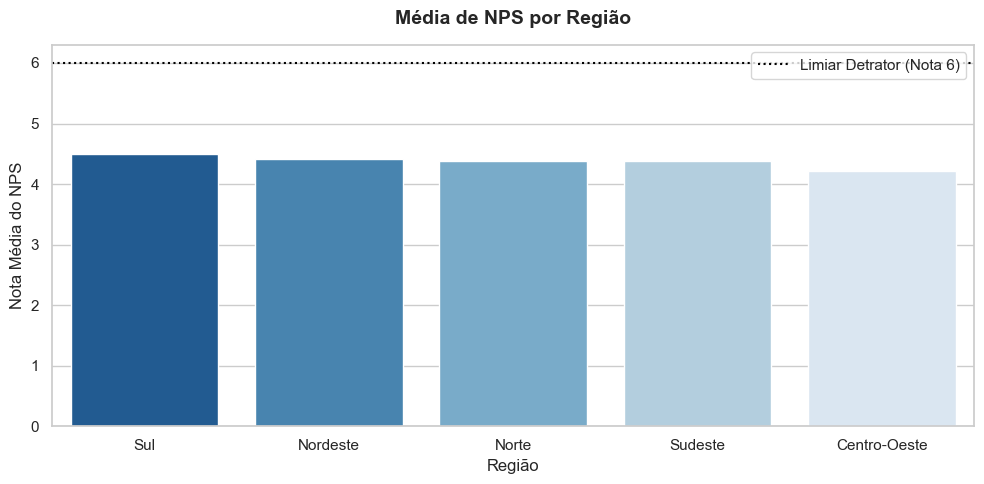

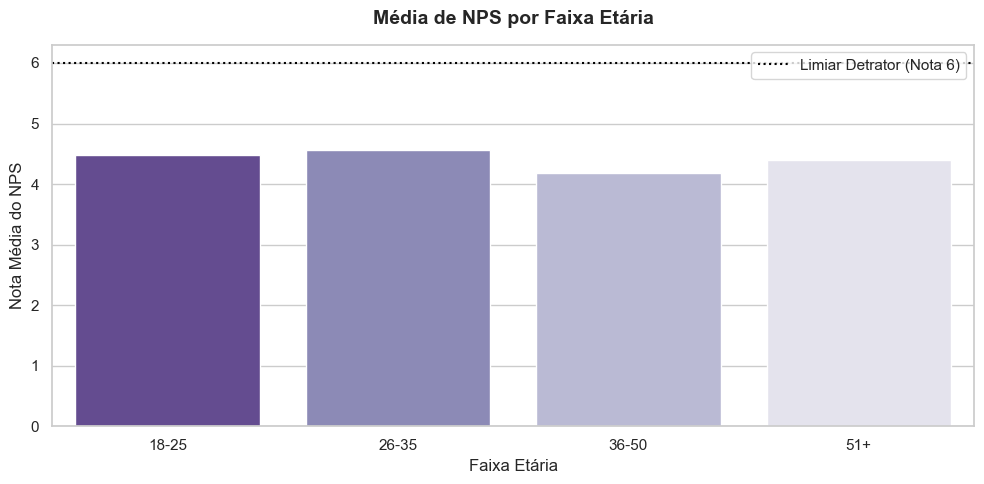

--- Média de NPS por Região ---
customer_region
Sul             4.49
Nordeste        4.42
Norte           4.38
Sudeste         4.37
Centro-Oeste    4.21
Name: nps_score, dtype: float64

--- Média de NPS por Faixa Etária ---
age_group
18-25    4.48
26-35    4.56
36-50    4.19
51+      4.40
Name: nps_score, dtype: float64


In [10]:
# 1. Análise por Região
plt.figure(figsize=(10, 5))
# Ordenando as barras pela média do NPS para facilitar a leitura
ordem_regiao = df.groupby('customer_region')['nps_score'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='customer_region', y='nps_score', order=ordem_regiao, palette='Blues_r', errorbar=None)

plt.title('Média de NPS por Região', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Nota Média do NPS', fontsize=12)
plt.axhline(y=6, color='black', linestyle=':', label='Limiar Detrator (Nota 6)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Análise por Faixa Etária
# Criando faixas etárias para facilitar a visualização gerencial
df['age_group'] = pd.cut(df['customer_age'], bins=[17, 25, 35, 50, 100], labels=['18-25', '26-35', '36-50', '51+'])

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='age_group', y='nps_score', palette='Purples_r', errorbar=None)

plt.title('Média de NPS por Faixa Etária', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Nota Média do NPS', fontsize=12)
plt.axhline(y=6, color='black', linestyle=':', label='Limiar Detrator (Nota 6)')
plt.legend()
plt.tight_layout()
plt.show()

# Exibindo os números exatos
print("--- Média de NPS por Região ---")
print(df.groupby('customer_region')['nps_score'].mean().round(2).sort_values(ascending=False))

print("\n--- Média de NPS por Faixa Etária ---")
print(df.groupby('age_group', observed=False)['nps_score'].mean().round(2))

Interpretação:

O fato de a nota ser consistentemente ruim (entre 4.1 e 4.5) em todas as regiões e em todas as idades prova que o problema da empresa não é localizado, é sistêmico.
Não estamos lidando com um problema de uma transportadora ruim no Centro-Oeste ou com um aplicativo difícil de usar para clientes mais velhos. A nossa operação centralizada de expedição e logística está falhando com o Brasil inteiro e com todos os perfis de consumidores de forma igualitária.